# Final project information

You have these 2 options to choose from

1. Minimizing edge crosssing in graph layout
2. Choose your own project

Details below

## 1. Graph Layout Optimization




In this project, you will formulate **graph layout optimization** as a **reinforcement learning (RL)** problem. The objective is to learn a policy that iteratively improves a graph drawing by **minimizing the number of edge crossings**, a central aesthetic criterion in graph visualization.

You will work with graphs from the **Rome graph collection**. Each episode starts from an initial layout (e.g., 'neato'), and the RL agent applies layout modifications over multiple steps to improve the drawing.


#### What is graph layout?

Say you have this social network, it is not clear what's the structure of this network
```
{Farid—Aadil, Latif—Aadil, Farid—Latif,
Carol—Andre, Carol—Fernando, Carol—Diane, Andre—Diane, Farid—Izdihar, Andre—Fernando, Izdihar—Mawsil, Andre—Beverly, Jane—Farid, Fernando—Diane, Fernando—Garth, Fernando—Heather, Diane—Beverly, Diane—Garth, Diane—Ed, Beverly—Garth, Beverly—Ed, Garth—Ed, Garth—Heather, Jane—Aadil, Heather—Jane, Mawsil—Latif}

```
But if you assign each node of this graph a coordinate in a proper way, and visualize it in 2D, this visualization gives a very clear cluster structure of the network

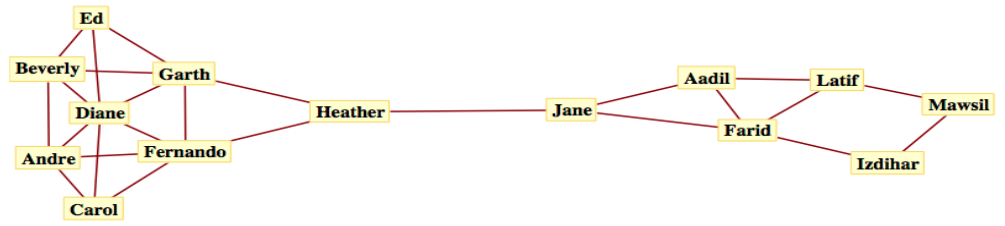

So the goal of graph layout is to assign coordinates to the nodes, in a way that reveal the structure. See this [graph visualization gallery](http://yifanhu.net/GALLERY/GRAPHS/index.html) I created for some examples

#### How to do graph visualization

There are libraries, e.g.,



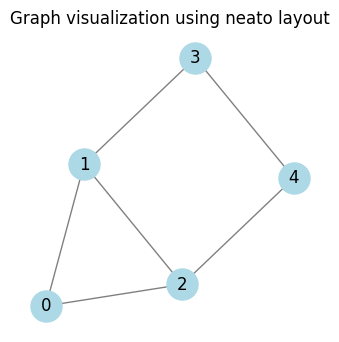

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a simple graph
G = nx.Graph()
G.add_edges_from([
    (0, 1), (0, 2), (1, 2),
    (1, 3), (2, 4), (3, 4)
])

# Compute layout using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(G, prog="neato") # replace neato with sfdp, fdp, etc

# Draw the graph
plt.figure(figsize=(3, 3))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    edge_color="gray"
)
plt.title("Graph visualization using neato layout")
plt.show()

#### What we try to optimize?



- There are many heuristics, all based on minimizing some metrics, e.g., some methods minimizes the stress (e.g., the "neato" method above)

$$
\mathrm{Stress}(X)
\;=\;
\sum_{i < j} w_{ij}
\left(
\| x_i - x_j \| - d_{ij}
\right)^2
$$

where

- $x_i \in \mathbb{R}^2$ is the coordinate of node $i$ in the layout $X$,
- $\| x_i - x_j \|$ is the Euclidean distance between nodes $i$ and $j$ in the drawing,
- $d_{ij}$ is the target (graph-theoretic) distance between nodes $i$ and $j$,
- $w_{ij}$ is a weighting term, commonly chosen as $w_{ij} = d_{ij}^{-2}$.

- These kind of metrics are differentiable, hence can be solved using gradient based method.
- **But we are not intersted in this kind of metric here**

#### Can the metric be non-differentiable

- One of the metric we like to minimize is the **edge crossing** ideally we want to minimize the number of edge crossings. E.g., in this image, the left one has 1 crossing, the right one 0, both visualize the same graph. The right one is preferred.

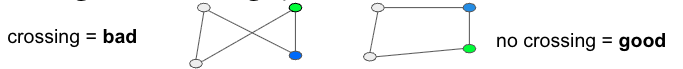

#### Now tell me the problem!

- If the metric is not differentiable, we can not optimize it easily with gradient based method
- **The problem**: can we use RL to solve it?

#### WARNING:
- This is **not a solved problem!!**, it's a research problem, and if your method works well, **we can write a paper and submit to a conference!**.
- I have tried RL for this, it can work, but I have not tried very hard, and I like to see if you can do better!



#### State

- A graph layout is represented by node coordinates $x_v = [x^1_v, x^2_v]$ for each node $v \in V$, the whole layout is a $|V|\times 2$ array $x$, like $x = [[0.,0.],[1.,0],[0.5, 0.866]]$ (A 3 nodes graph {1--2,2--3,3--1} laid out as a triangle)

#### Initial state
- Use the NetworkX to get the 'neato' or 'sfdp' layout as your starting layout (state). They tend to give relatively small edge crossing.

#### Action (Your Design Choice)

Examples: 

- starting from layout $x$, action is $\Delta x\in R^{|V|\times 2}$, which is the delta change to the corrent layout. The result is $x \leftarrow x + \Delta x$ which is the $S_{t+1}$
- Or the action is to move one node at a time, like $\Delta x_i\in R^{2}$, and the result is $x_i \leftarrow x_i + \Delta x_i$.


#### Reward
- Primary reward: **improvement in edge crossings**
  
  $$
  R_{t+1} = \text{crossings}_{t+1} - \text{crossings}_t
  $$

- Reward shaping is allowed (e.g., limiting large moves)


#### Episode Termination
- Fixed number of steps, **or**
- No further improvement over a fixed number of steps


#### Methods
You may use any suitable RL or optimization method, including but not limited to:
- Policy gradient methods (e.g., REINFORCE, PPO, GRPO)
- Actor–critic methods
- ...

If you are using policy gradient, then likely you will need to also use neural network/graph neural network as a policy network. But don't let any of these ideas limit you.

You are encouraged to start with a simple method and progressively refine it.


#### Evaluation

- Models should be trained only on the training set, and evaluated on the test set. 

- Ideally if your model is reusable, i.e., once trained, I can feed a new graph, and it will give me a layout that minimizes the edge crossing without going through the whole RL process.

- But if that's is difficult, then I can accept a model that takes a new graph, and does the whole RL process.

- The resulting edge crossings are used as the evaluation metric.

- For example, ifyou have 3 test graphs, the initial layout has edge crossing 10,20,15; your model has edge crossings 9, 12, 16. Then the relative improvement is defined as

mean[ (9-10)/max(9,10), (12-20)/max(12, 20), (16-15)/max(16,15)]=(-0.1-0.4+0.0615)=-0.1458

- This means that your model is 14.58% better than the baseline model of 'neato.

#### Baselines:
- Comparison against at least 3 baseline: 
   - 'neato'
   - 'sfdp'
   - Column xing in https://github.com/yolandalalala/GraphDrawingBenchmark/blob/main/metrics.csv (this is the xing achieved by a model called [SmartGD](https://arxiv.org/abs/2206.06434))

- You may also add baselines that uses derivative-free optimizations

#### Competition/extra credit

- If there are more than 3 teams, the top team with the best improvement get 5% extra credit, top 1/3 teams gets 2% extra credit.

#### Deliverables

- In addition to the usual deliverables (updates, presentation, report), please submit link in your report to the **code in github** with clear instructions for reproduction.

#### Datasets

- You should use Rome dataset. Please only use up to graph 9999 for your development, and test on graphs 10000-10100.

https://graphdrawing.unipg.it/data/rome-graphml.tgz


#### Notes
- Efficiency matters: computing edge crossings can be expensive.
- Creativity in state, action, or reward design is encouraged.


#### Codes toget you started

- I have includes a code that computes the edge-crossings gigen a NetworrkX graph. It's not very efficient, may be you can code a more efficient one if you like.

In [8]:
from xing import XingLoss

Loaded graph with 24 nodes and 33 edges
Number of edge crossings: 3.0


/var/folders/_g/n0knlsp942s11n6cyn4rs0800000gn/T/ipykernel_56841/1894925628.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords = torch.tensor(coords, dtype=torch.float32)


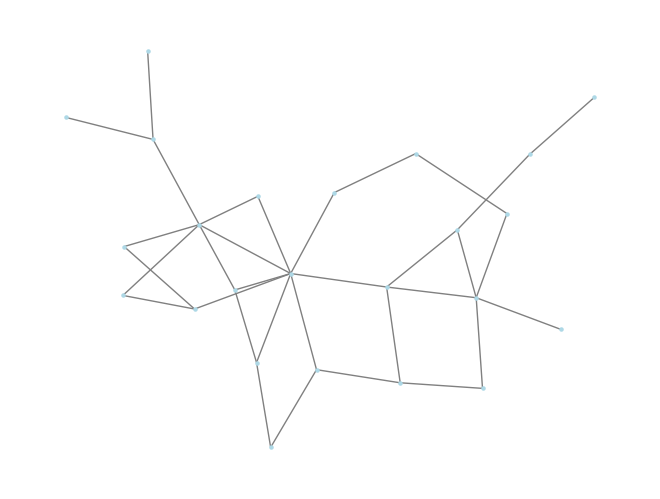

In [13]:
import networkx as nx
import torch
import numpy as np

graphml_path = "rome/grafo119.24.graphml"   # path to your GraphML file
G = nx.read_graphml(graphml_path)

# Ensure nodes are in a fixed order
G = nx.convert_node_labels_to_integers(G, ordering="sorted")

print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

pos = nx.nx_agraph.graphviz_layout(G, prog="neato")

nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=5,
    node_color="lightblue",
    edge_color="gray"
)

coords = []

coords = torch.tensor(
    [[pos[v][0], pos[v][1]] for v in G.nodes()],
    dtype=torch.float32
)

coords = torch.tensor(coords, dtype=torch.float32)

# -----------------------------
# 2. Instantiate crossing loss
# -----------------------------
xing_loss = XingLoss(G, soft=False)

# -----------------------------
# 3. Compute crossings
# -----------------------------
crossings = xing_loss(coords)

print("Number of edge crossings:", crossings.item())



Loaded graph with 24 nodes and 33 edges
Number of edge crossings: 3.0


/var/folders/_g/n0knlsp942s11n6cyn4rs0800000gn/T/ipykernel_56841/3853610038.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords = torch.tensor(coords, dtype=torch.float32)


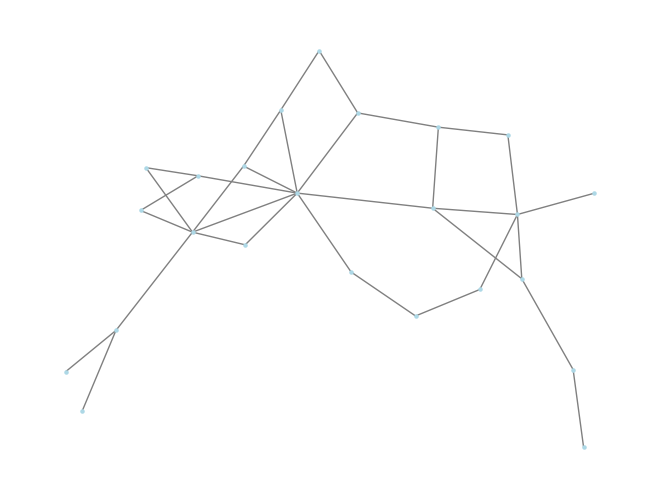

In [15]:
import networkx as nx
import torch
import numpy as np

graphml_path = "rome/grafo119.24.graphml"   # path to your GraphML file
G = nx.read_graphml(graphml_path)

# Ensure nodes are in a fixed order
G = nx.convert_node_labels_to_integers(G, ordering="sorted")

print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

pos = nx.nx_agraph.graphviz_layout(G, prog="sfdp")

nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=5,
    node_color="lightblue",
    edge_color="gray"
)

coords = []

coords = torch.tensor(
    [[pos[v][0], pos[v][1]] for v in G.nodes()],
    dtype=torch.float32
)

coords = torch.tensor(coords, dtype=torch.float32)

# -----------------------------
# 2. Instantiate crossing loss
# -----------------------------
xing_loss = XingLoss(G, soft=False)

# -----------------------------
# 3. Compute crossings
# -----------------------------
crossings = xing_loss(coords)

print("Number of edge crossings:", crossings.item())



## Baseline: Differentiable Crossing Loss + Gradient Descent

Here we test optimizing the node coordinates directly using gradient descent. We use the `soft=True` version of `XingLoss` as our differentiable objective, and evaluate using the exact non-differentiable crossing count (`soft=False`).

Initial exact crossings: 3.0


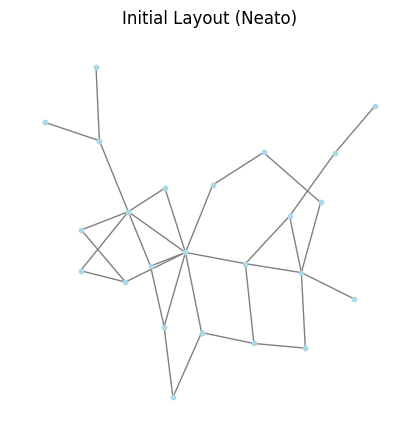


Starting optimization...
Epoch 050/300 | Soft Loss: 1.4313 | Exact Crossings: 2.0
Epoch 100/300 | Soft Loss: 1.3963 | Exact Crossings: 2.0
Epoch 150/300 | Soft Loss: 1.3905 | Exact Crossings: 2.0
Epoch 200/300 | Soft Loss: 1.3076 | Exact Crossings: 2.0
Epoch 250/300 | Soft Loss: 1.2911 | Exact Crossings: 2.0
Epoch 300/300 | Soft Loss: 1.1982 | Exact Crossings: 2.0

Final exact crossings: 2.0
Improvement: 1.0 crossings


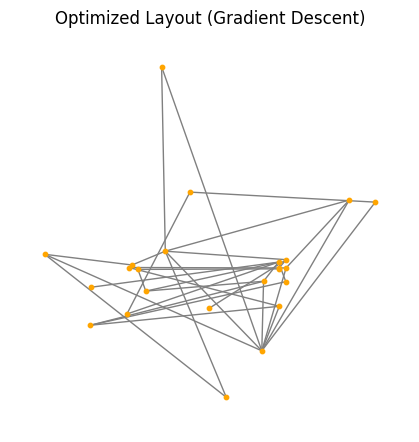

In [16]:
import networkx as nx
import torch
import matplotlib.pyplot as plt
from torch.optim import Adam
from xing import XingLoss

# 1. Load the graph and get initial layout
graphml_path = "rome/grafo119.24.graphml"
G = nx.read_graphml(graphml_path)
G = nx.convert_node_labels_to_integers(G, ordering="sorted")

# Use neato as initial layout
pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
coords = torch.tensor(
    [[pos[v][0], pos[v][1]] for v in G.nodes()],
    dtype=torch.float32,
    requires_grad=True
)

# 2. Instantiate losses: soft for training, hard for evaluation
xing_loss_soft = XingLoss(G, soft=True)
xing_loss_hard = XingLoss(G, soft=False)

initial_hard_loss = xing_loss_hard(coords).item()
print(f"Initial exact crossings: {initial_hard_loss}")

plt.figure(figsize=(4, 4))
nx.draw(G, pos, with_labels=False, node_size=10, node_color="lightblue", edge_color="gray")
plt.title("Initial Layout (Neato)")
plt.show()

# 3. Optimize with Adam
optimizer = Adam([coords], lr=2.0) # node coordinates are often >100, so a larger LR makes it faster
epochs = 300

print("\nStarting optimization...")
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = xing_loss_soft(coords)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            hard_loss = xing_loss_hard(coords).item()
            print(f"Epoch {epoch+1:03d}/{epochs} | Soft Loss: {loss.item():.4f} | Exact Crossings: {hard_loss}")

# 4. Final Evaluation & Visualization
final_hard_loss = xing_loss_hard(coords).item()
print(f"\nFinal exact crossings: {final_hard_loss}")
print(f"Improvement: {initial_hard_loss - final_hard_loss} crossings")

final_pos = {i: coords[i].detach().numpy() for i in range(G.number_of_nodes())}

plt.figure(figsize=(4, 4))
nx.draw(
    G,
    final_pos,
    with_labels=False,
    node_size=10,
    node_color="orange",
    edge_color="gray"
)
plt.title("Optimized Layout (Gradient Descent)")
plt.show()
